# LightGBM 数据探索与验证结果

沿用小组 Notebook 的结构：检查共同数据集、查看历史特征、加载已完成实验、比较基线、分析预测误差。

本 Notebook 展示 AAPL **下一交易日收益率回归**。输入为最近 60 个交易日、每天 8 个特征。仅分析训练期和 2022–2023 验证期，2024–2025 最终测试期与 2026 保留期未评价。

In [1]:
%matplotlib inline
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from lightgbm import Booster

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "configs/aapl.json").exists()), None)
if ROOT is None:
    raise RuntimeError("Cannot locate the EE6008 repository")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import FEATURES, load_dataset
from src.evaluate import evaluate, plot_comparison

RUN_NAME = "lgbm_aapl_validation_20261003"
run_dir = ROOT / "artifacts" / RUN_NAME
manifest = json.loads((run_dir / "manifest.json").read_text(encoding="utf-8"))
if manifest["status"] != "complete" or manifest["evaluation_split"] != "validation":
    raise ValueError("Select a completed validation experiment")
if manifest["test_evaluated"] or manifest["holdout_evaluated"]:
    raise ValueError("This notebook is limited to the validation experiment")

config = json.loads((run_dir / "config.json").read_text(encoding="utf-8"))
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
training = json.loads((run_dir / "training.json").read_text(encoding="utf-8"))["lightgbm"]
preprocessing = json.loads((run_dir / "preprocessing.json").read_text(encoding="utf-8"))
reference = json.loads((run_dir / "direction_reference.json").read_text(encoding="utf-8"))
dataset = load_dataset(config, ROOT)
current_hash = hashlib.sha256((ROOT / config["data_path"]).read_bytes()).hexdigest()
assert current_hash == manifest["data_sha256"], "Raw data version changed"

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
pd.set_option("display.max_columns", 12)
print("Experiment:", RUN_NAME)
print("Model: LightGBM. Seed:", config["seed"])
print("Evaluation: validation only. Model is not retrained here.")

Experiment: lgbm_aapl_validation_20261003
Model: LightGBM. Seed: 42
Evaluation: validation only. Model is not retrained here.


## 1. 检查统一数据集

使用公共 `src/data.py` 构造样本。每个样本的目标为 `close[t+1] / close[t] - 1`，按目标日期切分，不随机打乱。标准化只使用训练窗口中的唯一历史日期。

下表中的日期是**预测目标日**，不是输入窗口的起点。

In [2]:
partitions = pd.DataFrame([
    {"Split": "Training", "Samples": len(dataset.train.y),
     "First target": dataset.audit["train_target_first"],
     "Last target": dataset.audit["train_target_last"]},
    {"Split": "Validation", "Samples": len(dataset.validation.y),
     "First target": dataset.audit["validation_target_first"],
     "Last target": dataset.audit["validation_target_last"]},
])
display(partitions.set_index("Split"))
print("Training input shape:", dataset.train.X.shape)
print("Validation input shape:", dataset.validation.X.shape)
print("Scaler input dates:", dataset.audit["scaler_first_date"],
      "to", dataset.audit["scaler_last_date"])
print("Final test period: 2024-2025, not evaluated.")
display(dataset.validation.dates.head().style.format({
    "window_start": lambda x: x.strftime("%Y-%m-%d"),
    "signal_date": lambda x: x.strftime("%Y-%m-%d"),
    "target_date": lambda x: x.strftime("%Y-%m-%d"),
}))

,Samples,First target,Last target
Split,,,
Training,2960,2010-04-01,2021-12-31
Validation,501,2022-01-03,2023-12-29


Training input shape: (2960, 60, 8)
Validation input shape: (501, 60, 8)
Scaler input dates: 2010-01-05 to 2021-12-30
Final test period: 2024-2025, not evaluated.


,window_start,signal_date,target_date
0,2021-10-07,2021-12-31,2022-01-03
1,2021-10-08,2022-01-03,2022-01-04
2,2021-10-11,2022-01-04,2022-01-05
3,2021-10-12,2022-01-05,2022-01-06
4,2021-10-13,2022-01-06,2022-01-07


## 2. 查看历史输入和模型设置

每天 8 个特征：AAPL 和 Nasdaq 各自的收益率、成交量变化、日内收益率与振幅。下表是**标准化前**的历史特征，小数 `0.01` 表示 1%。

树模型将 `[60, 8]` 按时间顺序展开为 480 列。最早一天是 `lag_59`，信号当天是 `lag_0`。LightGBM 同样使用过去 60 天，并非只看当天一行。

,return,vol_change,intraday_return,range,nasdaq_return,nasdaq_vol_change,nasdaq_intraday_return,nasdaq_range
date,,,,,,,,
2010-01-05 00:00:00,0.001729,0.219098,-0.001025,0.010915,0.000126,0.225994,0.000624,0.007844
2010-01-06 00:00:00,-0.015906,-0.082646,-0.015906,0.021235,-0.003300,-0.048364,-0.002869,0.007992
2010-01-07 00:00:00,-0.001849,-0.135882,-0.005525,0.014009,-0.000452,0.007416,0.000853,0.006991
2010-01-08 00:00:00,0.006648,-0.061871,0.007989,0.013869,0.007443,-0.054915,0.010876,0.011648
2010-01-11 00:00:00,-0.008821,0.032660,-0.012641,0.021655,-0.002054,-0.031463,-0.005321,0.010409
2010-01-12 00:00:00,-0.011375,0.286070,-0.007027,0.016128,-0.013017,0.139772,-0.006516,0.011458


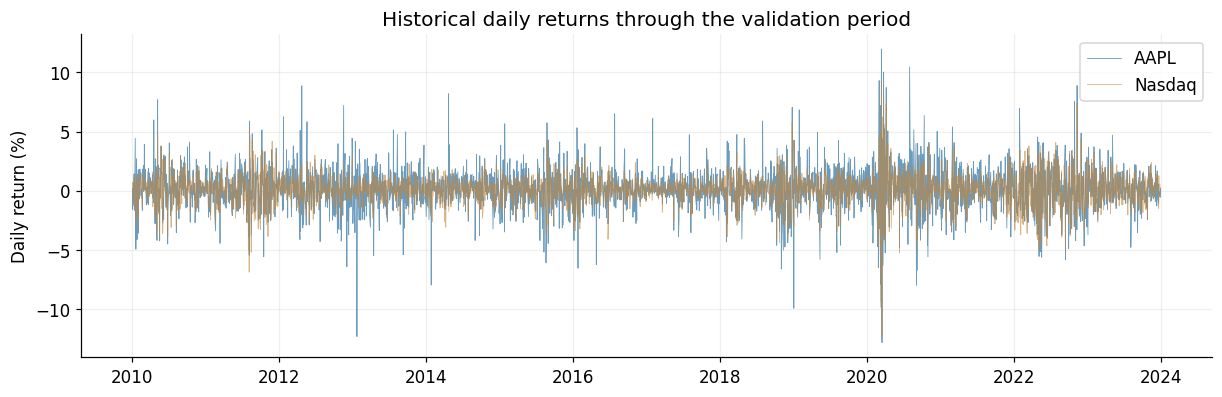

,Value
Parameter,
n_estimators,500.00
learning_rate,0.03
num_leaves,15.00
max_depth,4.00
min_child_samples,50.00
subsample,0.80
subsample_freq,1.00
colsample_bytree,0.80
reg_lambda,10.00


In [3]:
feature_preview = dataset.feature_frame.dropna().head(6).set_index("date")
display(feature_preview.style.format("{:.6f}"))
history = dataset.feature_frame.set_index("date")
fig, ax = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax.plot(history.index, history["return"] * 100, linewidth=0.55, alpha=0.8, label="AAPL", color="#4684ad")
ax.plot(history.index, history["nasdaq_return"] * 100, linewidth=0.55, alpha=0.6, label="Nasdaq", color="#c1843c")
ax.set(title="Historical daily returns through the validation period", ylabel="Daily return (%)")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

display(pd.Series(config["lightgbm"], name="Value").to_frame().rename_axis("Parameter"))

## 3. 比较收益误差和方向指标

同一批 501 个验证目标日用于比较 LightGBM 和三种简单基线：

- **Zero return**：预测次日收益为 0。
- **Historical mean**：预测次日收益为训练标签的平均值。
- **Last return**：预测次日收益与信号当天相同。

MAE/RMSE 使用**百分点（pp）**，例如 `1.8263 pp` 对应小数收益误差 `0.018263`。R² 为普通验证集 R²，`R2 vs zero` 为相对零收益基线的平方误差改善，二者不能混称。

方向由收益正负推导：`return > 0` 为上涨，否则为不涨。Precision、Recall、F1 的正类是上涨。

,N,MAE (pp),RMSE (pp),R2,R2 vs zero
Zero return,501,1.3611,1.8314,-0.000322,0.000000
Historical mean,501,1.3612,1.8331,-0.002203,-0.001880
Last return,501,1.9277,2.5931,-1.005448,-1.004802
LightGBM,501,1.3578,1.8263,0.005235,0.005556


,Accuracy,Precision,Recall,F1,Predicted up
Zero return,48.70%,0.0000,0.0000,0.0000,0.00%
Historical mean,51.30%,0.5130,1.0000,0.6781,100.00%
Last return,50.50%,0.5175,0.5175,0.5175,51.30%
LightGBM,51.10%,0.5127,0.9416,0.6639,94.21%


Train-majority direction accuracy on validation: 51.30%


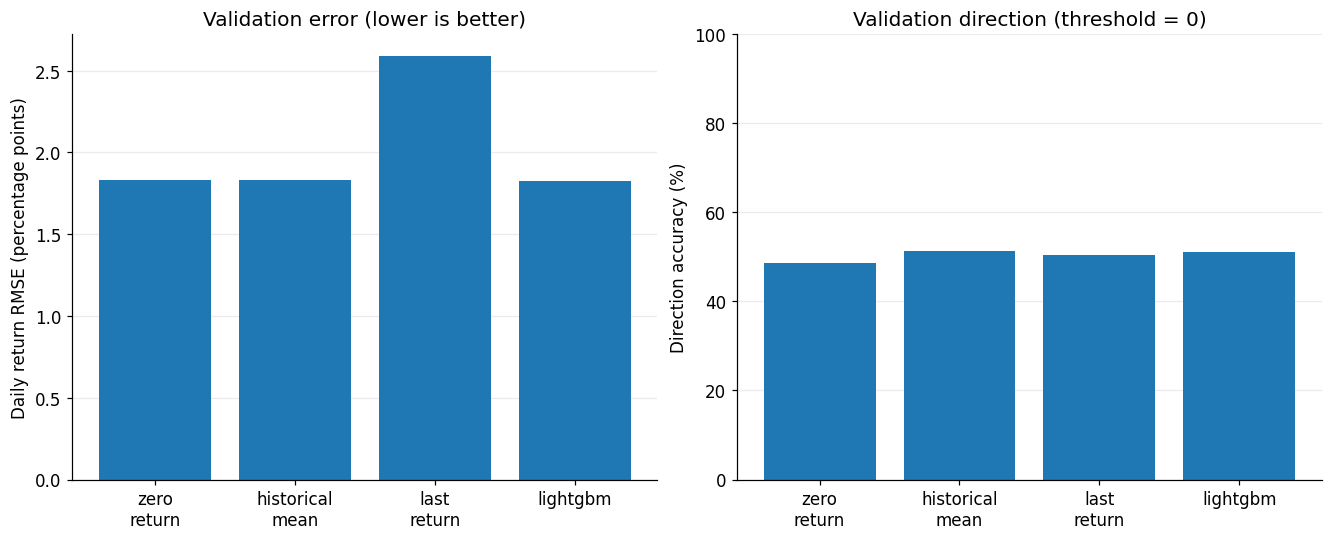

In [4]:
predictions = pd.read_csv(run_dir / "predictions.csv",
                          parse_dates=["window_start", "signal_date", "target_date"])
np.testing.assert_array_equal(predictions.target_date.to_numpy(),
                              dataset.validation.dates.target_date.to_numpy())
np.testing.assert_allclose(predictions.actual_return, dataset.validation.y, atol=1e-14)
for name, saved in metrics.items():
    recalculated = evaluate(predictions.actual_return.to_numpy(), predictions[name].to_numpy())
    for key in ("mae", "rmse", "r2", "r2_vs_zero", "direction_accuracy",
                "up_precision", "up_recall", "up_f1", "predicted_up_rate"):
        np.testing.assert_allclose(recalculated[key], saved[key], atol=1e-12)

names = {"zero_return": "Zero return", "historical_mean": "Historical mean",
         "last_return": "Last return", "lightgbm": "LightGBM"}
summary = pd.DataFrame(metrics).T
regression = summary[["n", "mae", "rmse", "r2", "r2_vs_zero"]].astype(float).copy()
regression["n"] = regression["n"].astype(int)
regression[["mae", "rmse"]] *= 100
regression = regression.rename(index=names, columns={
    "n": "N", "mae": "MAE (pp)", "rmse": "RMSE (pp)",
    "r2": "R2", "r2_vs_zero": "R2 vs zero"})
direction = summary[["direction_accuracy", "up_precision", "up_recall",
                     "up_f1", "predicted_up_rate"]].astype(float).rename(
    index=names, columns={"direction_accuracy": "Accuracy", "up_precision": "Precision",
                         "up_recall": "Recall", "up_f1": "F1",
                         "predicted_up_rate": "Predicted up"})
display(regression.style.format({"N": "{:d}", "MAE (pp)": "{:.4f}",
                                 "RMSE (pp)": "{:.4f}", "R2": "{:.6f}", "R2 vs zero": "{:.6f}"}))
display(direction.style.format({"Accuracy": "{:.2%}", "Precision": "{:.4f}",
                                "Recall": "{:.4f}", "F1": "{:.4f}", "Predicted up": "{:.2%}"}))
print("Train-majority direction accuracy on validation:",
      f"{reference['validation_accuracy']:.2%}")
fig = plot_comparison(metrics)
plt.show()

## 4. 检查逐日预测

预测表按目标交易日对齐。模型列是原始**小数收益率**，不是标准化值或类别标签。下方先看逐日记录，再看整个验证期和最后 80 个验证日。

展示最后 80 日是为了看清局部波动，不会改变全期指标。

,signal_date,target_date,actual_return,lightgbm
0,2021-12-31,2022-01-03,0.025004,0.001131
1,2022-01-03,2022-01-04,-0.012692,0.000716
2,2022-01-04,2022-01-05,-0.026600,0.001976
3,2022-01-05,2022-01-06,-0.016693,0.000916
4,2022-01-06,2022-01-07,0.000988,-0.000385
5,2022-01-07,2022-01-10,0.000116,0.000567
6,2022-01-10,2022-01-11,0.016784,0.002358
7,2022-01-11,2022-01-12,0.002570,0.000039


Saved-model predictions match all 501 CSV rows.


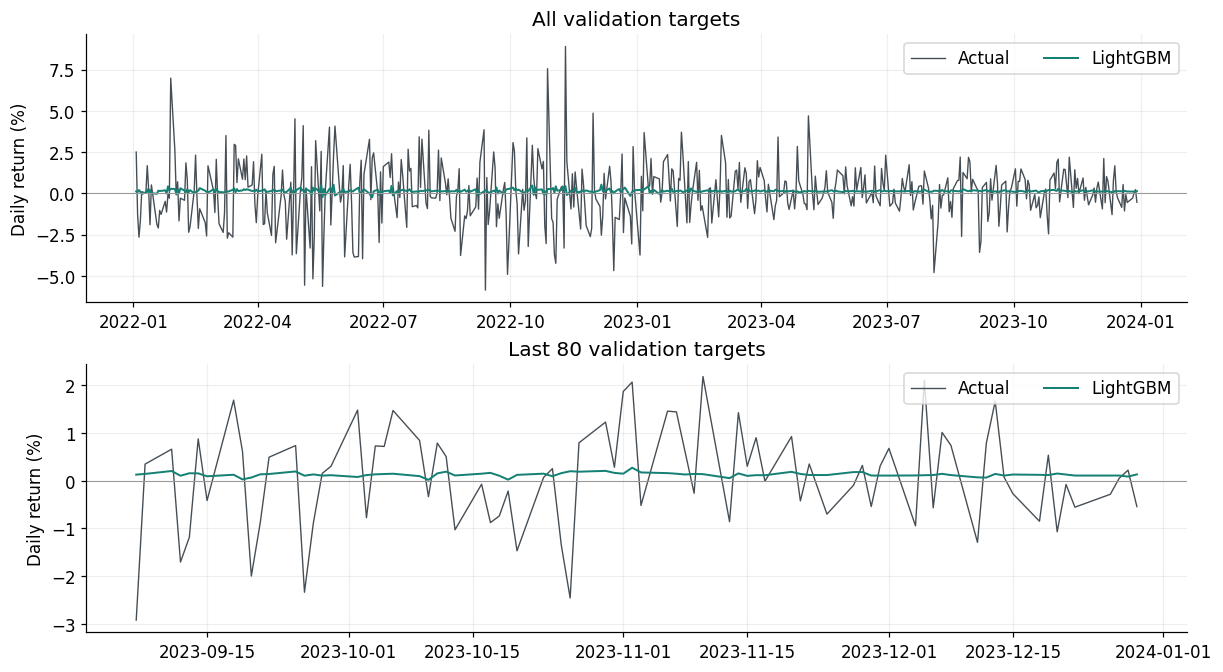

In [5]:
display(predictions[["signal_date", "target_date", "actual_return", "lightgbm"]].head(8).style.format({
    "signal_date": lambda x: x.strftime("%Y-%m-%d"),
    "target_date": lambda x: x.strftime("%Y-%m-%d"),
    "actual_return": "{:.6f}", "lightgbm": "{:.6f}"}))

booster = Booster(model_file=str(run_dir / "lightgbm.txt"))
validation_x = dataset.transform(dataset.validation.X).reshape(len(dataset.validation.y), -1)
restored_prediction = booster.predict(validation_x) * dataset.target_scale + dataset.target_mean
np.testing.assert_allclose(restored_prediction, predictions.lightgbm, atol=1e-12)
print("Saved-model predictions match all", len(predictions), "CSV rows.")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), layout="constrained")
for ax, data, title in zip(axes, [predictions, predictions.tail(80)],
                           ["All validation targets", "Last 80 validation targets"]):
    ax.plot(data.target_date, data.actual_return * 100, label="Actual", color="#464e55", linewidth=0.9)
    ax.plot(data.target_date, data.lightgbm * 100, label="LightGBM", color="#168074", linewidth=1.3)
    ax.axhline(0, color="#999999", linewidth=0.7)
    ax.set(title=title, ylabel="Daily return (%)")
    ax.legend(loc="upper right", ncol=2)
    ax.grid(alpha=0.2)
plt.show()

## 5. 查看训练过程

最大训练轮次为 500，但只保存验证 RMSE 最低的树前缀。虚线标记被选中的轮次；之后继续训练是为了判断是否触发早停，不会把后续树加入已保存模型。

训练记录中的 RMSE 已恢复为**原始收益百分点**，便于与结果表比较。

,Selected iteration,Iterations evaluated,Flattened features,Device,Training seconds
0,16,46,480,cpu,0.166


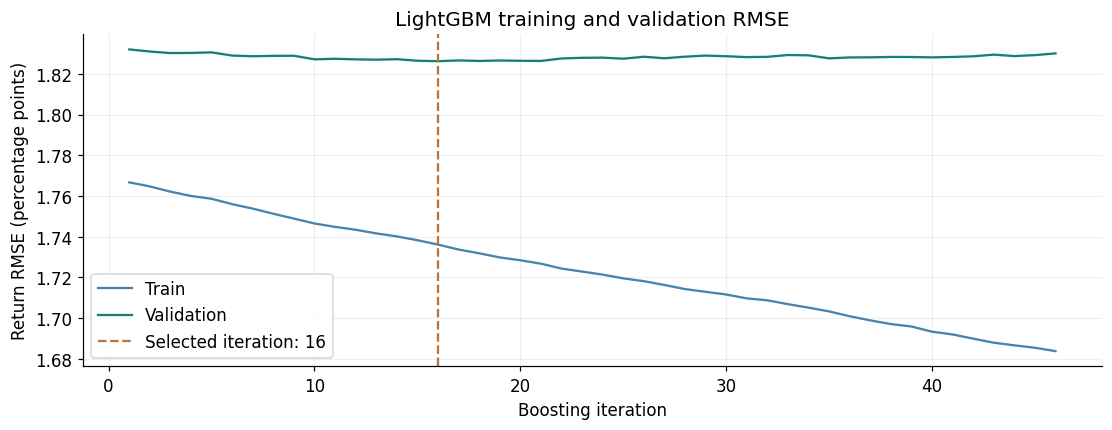

In [6]:
train_rmse = np.asarray(training["history"]["train"]["rmse"]) * dataset.target_scale * 100
validation_rmse = np.asarray(training["history"]["validation"]["rmse"]) * dataset.target_scale * 100
best = training["best_iteration"]
np.testing.assert_allclose(validation_rmse[best - 1], metrics["lightgbm"]["rmse"] * 100,
                           atol=1e-7)
display(pd.DataFrame([{
    "Selected iteration": best, "Iterations evaluated": training["iterations_run"],
    "Flattened features": training["n_features"], "Device": training["device"],
    "Training seconds": training["seconds"],
}]).style.format({"Training seconds": "{:.3f}"}))
fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
ax.plot(np.arange(1, len(train_rmse) + 1), train_rmse, label="Train", color="#4684ad")
ax.plot(np.arange(1, len(validation_rmse) + 1), validation_rmse, label="Validation", color="#168074")
ax.axvline(best, linestyle="--", color="#b57540", label=f"Selected iteration: {best}")
ax.set(title="LightGBM training and validation RMSE", xlabel="Boosting iteration",
       ylabel="Return RMSE (percentage points)")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## 6. 分析方向偏差

准确率约 51% 不代表模型已经学会预测涨跌。需要同时看预测上涨比例和混淆矩阵。

矩阵的行是真实方向，列是预测方向；平盘归入“不涨”。每格同时显示样本数和占该真实类别的比例。

,Predicted not up,Predicted up
Actual not up,14,230
Actual up,15,242


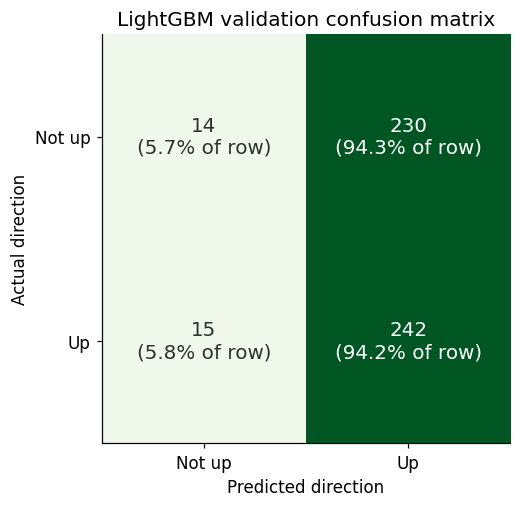

In [7]:
cm = np.asarray(metrics["lightgbm"]["confusion_matrix"])
display(pd.DataFrame(cm, index=["Actual not up", "Actual up"],
                     columns=["Predicted not up", "Predicted up"]))
row_rates = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 4.5), layout="constrained")
ax.imshow(row_rates, cmap="Greens", vmin=0, vmax=1)
for r in range(2):
    for c in range(2):
        ax.text(c, r, f"{cm[r, c]}\n({row_rates[r, c]:.1%} of row)",
                ha="center", va="center", fontsize=13,
                color="white" if row_rates[r, c] > 0.6 else "#29362e")
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Not up", "Up"],
       yticklabels=["Not up", "Up"], xlabel="Predicted direction",
       ylabel="Actual direction", title="LightGBM validation confusion matrix")
plt.show()

## 7. 查看特征重要性

读取本次保存的最佳 LightGBM 模型，将同一特征在 60 个滞后日上的**训练分裂增益**相加。这说明模型如何使用训练输入，不是因果解释，也不能证明这些特征在新时期仍然有效。

,Share of split gain
range,21.43%
nasdaq_return,20.44%
nasdaq_range,16.23%
return,15.11%
intraday_return,9.44%
nasdaq_vol_change,6.73%
vol_change,5.51%
nasdaq_intraday_return,5.11%


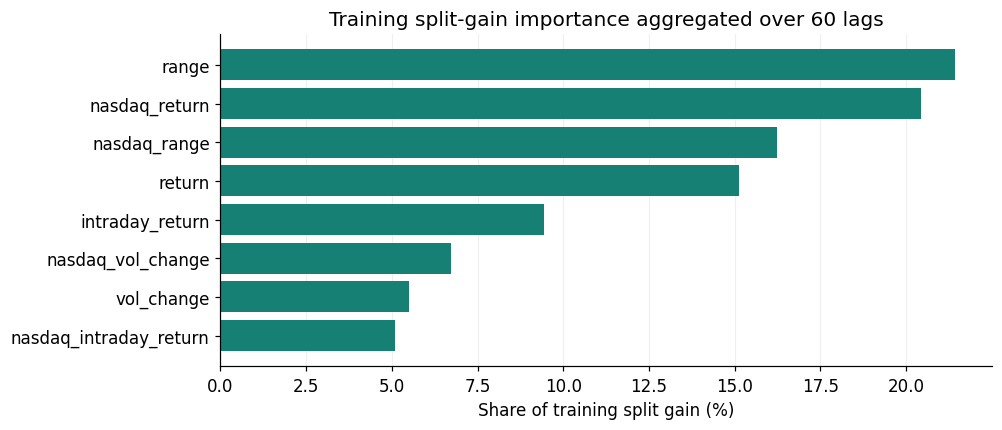

In [8]:
gain_by_feature = dict.fromkeys(FEATURES, 0.0)
for feature, gain in zip(booster.feature_name(), booster.feature_importance(importance_type="gain")):
    gain_by_feature[feature.split("_", 2)[2]] += float(gain)
importance = pd.Series(gain_by_feature, name="Gain").sort_values(ascending=False)
total_gain = importance.sum()
importance_share = importance / total_gain if total_gain else importance * 0
display(importance_share.to_frame("Share of split gain").style.format("{:.2%}"))
fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
ordered = importance_share.sort_values()
ax.barh(ordered.index, ordered * 100, color="#168074")
ax.set(title="Training split-gain importance aggregated over 60 lags",
       xlabel="Share of training split gain (%)")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
plt.show()

## 8. 结果解释与简单英语汇报

本轮使用固定时间划分和单个随机种子，是模型接入与初步验证，不是最终测试成绩。收益回归误差与方向指标分开解释，不能只选表现较好的指标。

下一步是与小组其他模型核对共同日期、真实标签和实验配置，然后再决定是否需要进一步调参。最终测试集仍保留到共同方法确定后再评价。

In [9]:
lm = metrics["lightgbm"]
zero = metrics["zero_return"]
relative_change = 1 - lm["rmse"] / zero["rmse"]
display(Markdown(
    f"**本次结果：** LightGBM RMSE 为 {lm['rmse']:.6f}，相对零收益基线降低 "
    f"{relative_change:.2%}。方向准确率 {lm['direction_accuracy']:.2%}，"
    f"多数方向基线为 {reference['validation_accuracy']:.2%}。"
    f"模型在 {lm['predicted_up_rate']:.2%} 的验证日预测上涨，"
    f"因此目前只能说回归误差略有改善，不能宣称有稳定的方向预测优势。"
))
display(Markdown(
    f"**Simple English Report**\n\n"
    f"My model is LightGBM regression. I use the same AAPL data and next-day return target as the group. "
    f"I flatten the last 60 trading days and eight daily features into 480 columns. "
    f"I use training-period statistics for scaling and validation RMSE for early stopping. "
    f"The selected model has {best} trees. "
    f"Validation RMSE is {lm['rmse']:.6f}, slightly better than the zero-return baseline. "
    f"But direction accuracy is {lm['direction_accuracy']:.2%}, and the model predicts up too often. "
    f"We have not evaluated the final test set yet."
))

**本次结果：** LightGBM RMSE 为 0.018263，相对零收益基线降低 0.28%。方向准确率 51.10%，多数方向基线为 51.30%。模型在 94.21% 的验证日预测上涨，因此目前只能说回归误差略有改善，不能宣称有稳定的方向预测优势。

**Simple English Report**

My model is LightGBM regression. I use the same AAPL data and next-day return target as the group. I flatten the last 60 trading days and eight daily features into 480 columns. I use training-period statistics for scaling and validation RMSE for early stopping. The selected model has 16 trees. Validation RMSE is 0.018263, slightly better than the zero-return baseline. But direction accuracy is 51.10%, and the model predicts up too often. We have not evaluated the final test set yet.